<a href="https://colab.research.google.com/github/InowaR/colab/blob/main/TransformClouds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

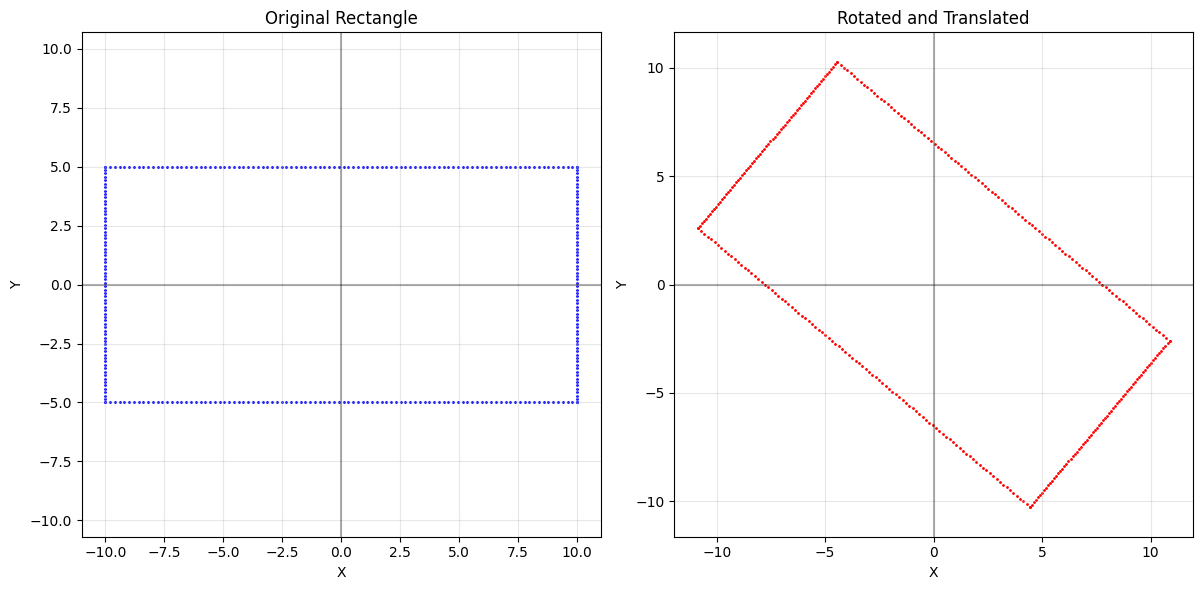

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def create_map(length, width):
    points = []
    half_length = length / 2
    half_width = width / 2

    for x in np.linspace(-half_length, half_length, 100):
        points.append([x, -half_width])
        points.append([x, half_width])

    for y in np.linspace(-half_width, half_width, 70):
        points.append([-half_length, y])
        points.append([half_length, y])

    return np.array(points)

def rotate_points(points, angle_deg):
    angle_rad = np.radians(angle_deg)
    rotation_matrix = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad), np.cos(angle_rad)]
    ])
    return np.dot(points, rotation_matrix.T)

def translate_points(points, dx, dy):
    return points + np.array([dx, dy])

rect1 = create_map(20, 10)

rect2 = create_map(20, 10)
rect2 = rotate_points(rect2, -40)
# rect2 = translate_points(rect2, -6, 4)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(rect1[:, 0], rect1[:, 1], s=1, c='blue')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title('Original Rectangle')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(1, 2, 2)
plt.scatter(rect2[:, 0], rect2[:, 1], s=1, c='red')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title('Rotated and Translated')
plt.xlabel('X')
plt.ylabel('Y')

plt.tight_layout()
plt.show()

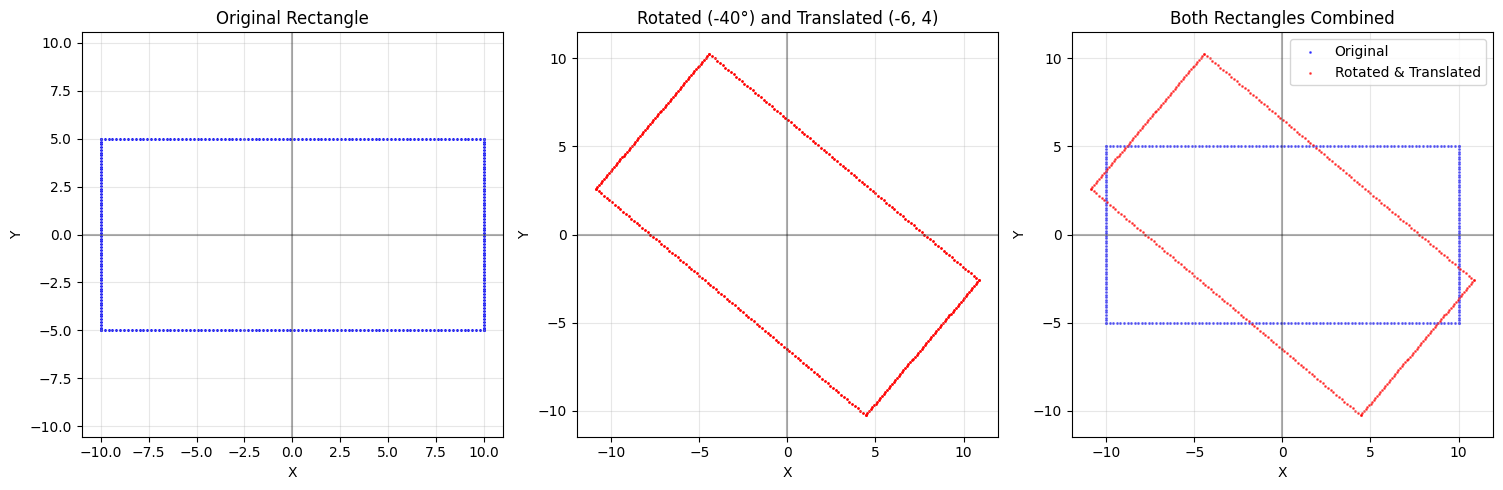

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def create_map(length, width):
    points = []
    half_length = length / 2
    half_width = width / 2

    for x in np.linspace(-half_length, half_length, 100):
        points.append([x, -half_width])
        points.append([x, half_width])

    for y in np.linspace(-half_width, half_width, 70):
        points.append([-half_length, y])
        points.append([half_length, y])

    return np.array(points)

def rotate_points(points, angle_deg):
    angle_rad = np.radians(angle_deg)
    rotation_matrix = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad), np.cos(angle_rad)]
    ])
    return np.dot(points, rotation_matrix.T)

def translate_points(points, dx, dy):
    return points + np.array([dx, dy])

rect1 = create_map(20, 10)

rect2 = create_map(20, 10)
rect2 = rotate_points(rect2, -40)
# rect2 = translate_points(rect2, -6, 4)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(rect1[:, 0], rect1[:, 1], s=1, c='blue')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title('Original Rectangle')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(1, 3, 2)
plt.scatter(rect2[:, 0], rect2[:, 1], s=1, c='red')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title('Rotated (-40°) and Translated (-6, 4)')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(1, 3, 3)
plt.scatter(rect1[:, 0], rect1[:, 1], s=1, c='blue', alpha=0.6, label='Original')
plt.scatter(rect2[:, 0], rect2[:, 1], s=1, c='red', alpha=0.6, label='Rotated & Translated')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title('Both Rectangles Combined')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.tight_layout()
plt.show()

Detected rotation: 40.00 degrees
Detected translation: dx = 0.00, dy = -0.00


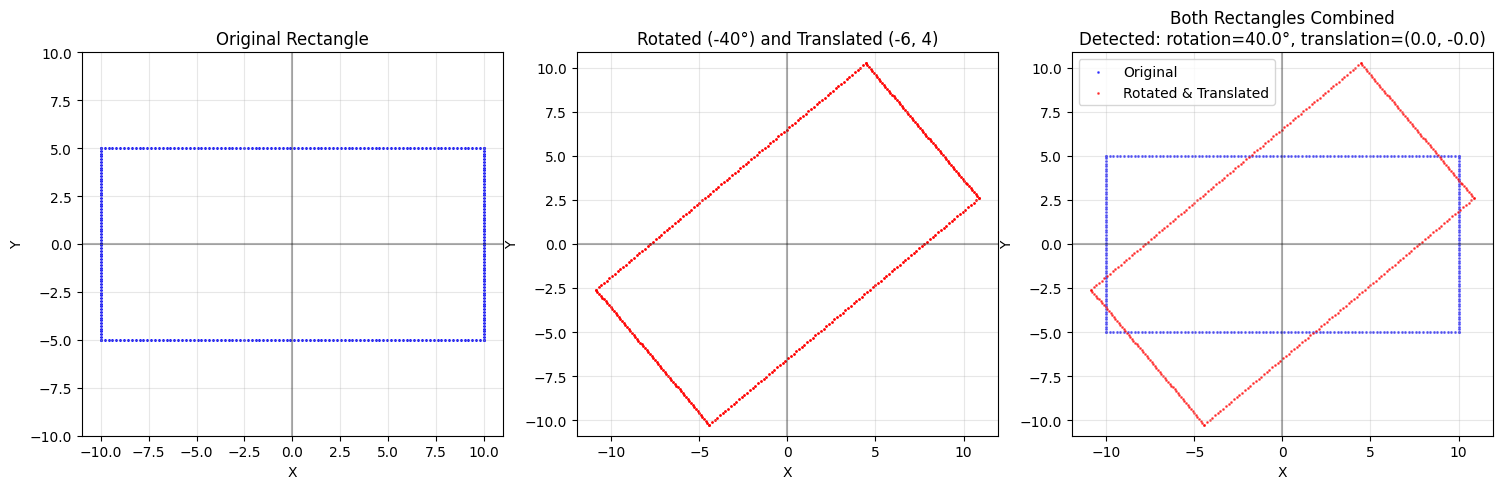

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def create_map(length, width):
    points = []
    half_length = length / 2
    half_width = width / 2

    for x in np.linspace(-half_length, half_length, 100):
        points.append([x, -half_width])
        points.append([x, half_width])

    for y in np.linspace(-half_width, half_width, 70):
        points.append([-half_length, y])
        points.append([half_length, y])

    return np.array(points)

def rotate_points(points, angle_deg):
    angle_rad = np.radians(angle_deg)
    rotation_matrix = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad), np.cos(angle_rad)]
    ])
    return np.dot(points, rotation_matrix.T)

def translate_points(points, dx, dy):
    return points + np.array([dx, dy])

def find_transform(source_points, target_points):
    source_center = np.mean(source_points, axis=0)
    target_center = np.mean(target_points, axis=0)

    translation = target_center - source_center

    source_centered = source_points - source_center
    target_centered = target_points - target_center

    H = np.dot(source_centered.T, target_centered)
    U, S, Vt = np.linalg.svd(H)
    R = np.dot(Vt.T, U.T)

    angle_rad = np.arctan2(R[1, 0], R[0, 0])
    angle_deg = np.degrees(angle_rad)

    return angle_deg, translation[0], translation[1]

rect1 = create_map(20, 10)

rect2 = create_map(20, 10)
rect2 = rotate_points(rect2, 40)
# rect2 = translate_points(rect2, -6, 4)

angle, dx, dy = find_transform(rect1, rect2)

print(f"Detected rotation: {angle:.2f} degrees")
print(f"Detected translation: dx = {dx:.2f}, dy = {dy:.2f}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(rect1[:, 0], rect1[:, 1], s=1, c='blue')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title('Original Rectangle')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(1, 3, 2)
plt.scatter(rect2[:, 0], rect2[:, 1], s=1, c='red')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title('Rotated (-40°) and Translated (-6, 4)')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(1, 3, 3)
plt.scatter(rect1[:, 0], rect1[:, 1], s=1, c='blue', alpha=0.6, label='Original')
plt.scatter(rect2[:, 0], rect2[:, 1], s=1, c='red', alpha=0.6, label='Rotated & Translated')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title(f'Both Rectangles Combined\nDetected: rotation={angle:.1f}°, translation=({dx:.1f}, {dy:.1f})')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.tight_layout()
plt.show()

Detected rotation: 126.00 degrees
Detected translation: dx = 17.00, dy = -8.00


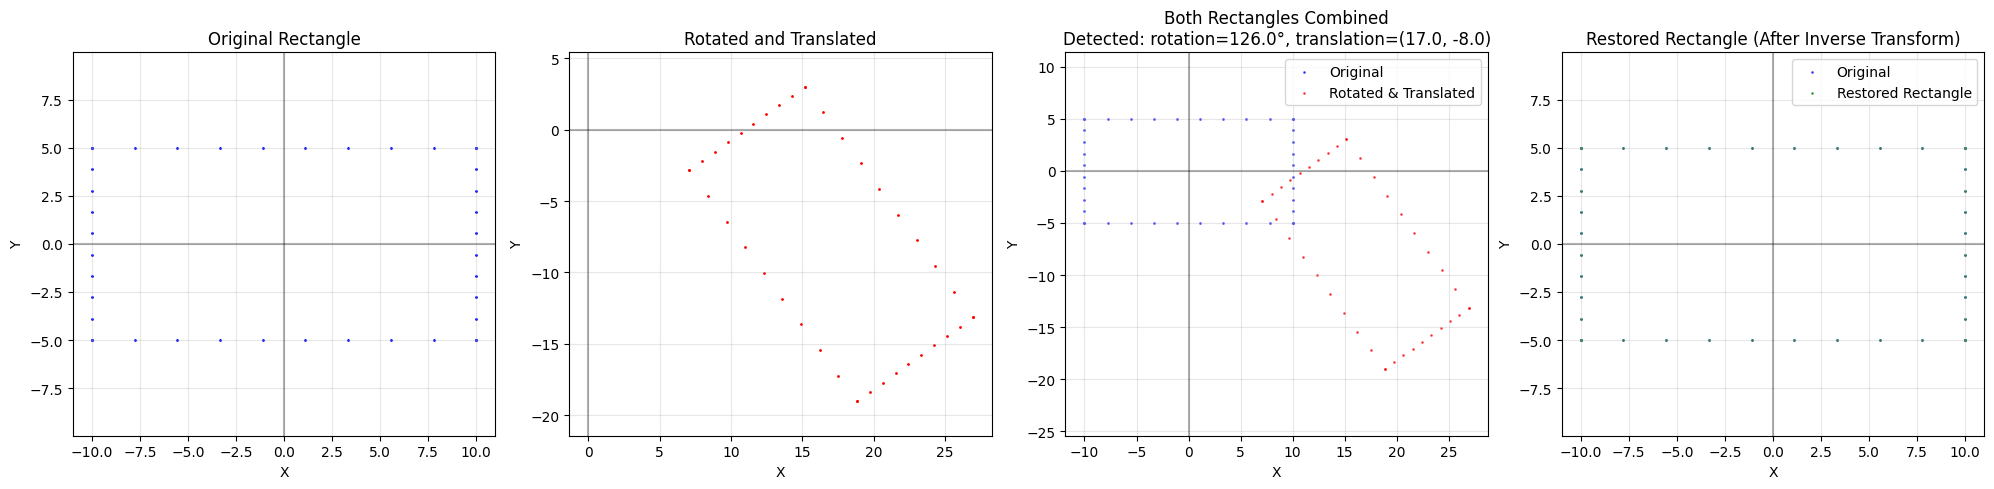

Restoration error (RMS): 0.000000


In [42]:
import numpy as np
import matplotlib.pyplot as plt

def create_map(length, width):
    points = []
    half_length = length / 2
    half_width = width / 2

    for x in np.linspace(-half_length, half_length, 10):
        points.append([x, -half_width])
        points.append([x, half_width])

    for y in np.linspace(-half_width, half_width, 10):
        points.append([-half_length, y])
        points.append([half_length, y])

    return np.array(points)

def rotate_points(points, angle_deg):
    angle_rad = np.radians(angle_deg)
    rotation_matrix = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad), np.cos(angle_rad)]
    ])
    return np.dot(points, rotation_matrix.T)

def translate_points(points, dx, dy):
    return points + np.array([dx, dy])

def find_transform(source_points, target_points):
    source_center = np.mean(source_points, axis=0)
    target_center = np.mean(target_points, axis=0)

    translation = target_center - source_center

    source_centered = source_points - source_center
    target_centered = target_points - target_center

    H = np.dot(source_centered.T, target_centered)
    U, S, Vt = np.linalg.svd(H)
    R = np.dot(Vt.T, U.T)

    angle_rad = np.arctan2(R[1, 0], R[0, 0])
    angle_deg = np.degrees(angle_rad)

    return angle_deg, translation[0], translation[1]

def inverse_transform(points, angle_deg, dx, dy):
    points_translated = translate_points(points, -dx, -dy)
    points_rotated = rotate_points(points_translated, -angle_deg)
    return points_rotated

rect1 = create_map(20, 10)

rect2 = create_map(20, 10)
rect2 = rotate_points(rect2, 126)
rect2 = translate_points(rect2, 17, -8)

angle, dx, dy = find_transform(rect1, rect2)

print(f"Detected rotation: {angle:.2f} degrees")
print(f"Detected translation: dx = {dx:.2f}, dy = {dy:.2f}")

rect2_restored = inverse_transform(rect2, angle, dx, dy)

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.scatter(rect1[:, 0], rect1[:, 1], s=1, c='blue')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title('Original Rectangle')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(1, 4, 2)
plt.scatter(rect2[:, 0], rect2[:, 1], s=1, c='red')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title('Rotated and Translated')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(1, 4, 3)
plt.scatter(rect1[:, 0], rect1[:, 1], s=1, c='blue', alpha=0.6, label='Original')
plt.scatter(rect2[:, 0], rect2[:, 1], s=1, c='red', alpha=0.6, label='Rotated & Translated')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title(f'Both Rectangles Combined\nDetected: rotation={angle:.1f}°, translation=({dx:.1f}, {dy:.1f})')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.subplot(1, 4, 4)
plt.scatter(rect1[:, 0], rect1[:, 1], s=1, c='blue', alpha=0.6, label='Original')
plt.scatter(rect2_restored[:, 0], rect2_restored[:, 1], s=1, c='green', alpha=0.6, label='Restored Rectangle')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title('Restored Rectangle (After Inverse Transform)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.tight_layout()
plt.show()

error = np.mean(np.sqrt(np.sum((rect1 - rect2_restored)**2, axis=1)))
print(f"Restoration error (RMS): {error:.6f}")

Rectangle 1 points after removing 20 random: 100
Rectangle 2 points after removing 20 from end: 100
Detected rotation: -25.67 degrees
Detected translation: dx = 17.36, dy = -7.66


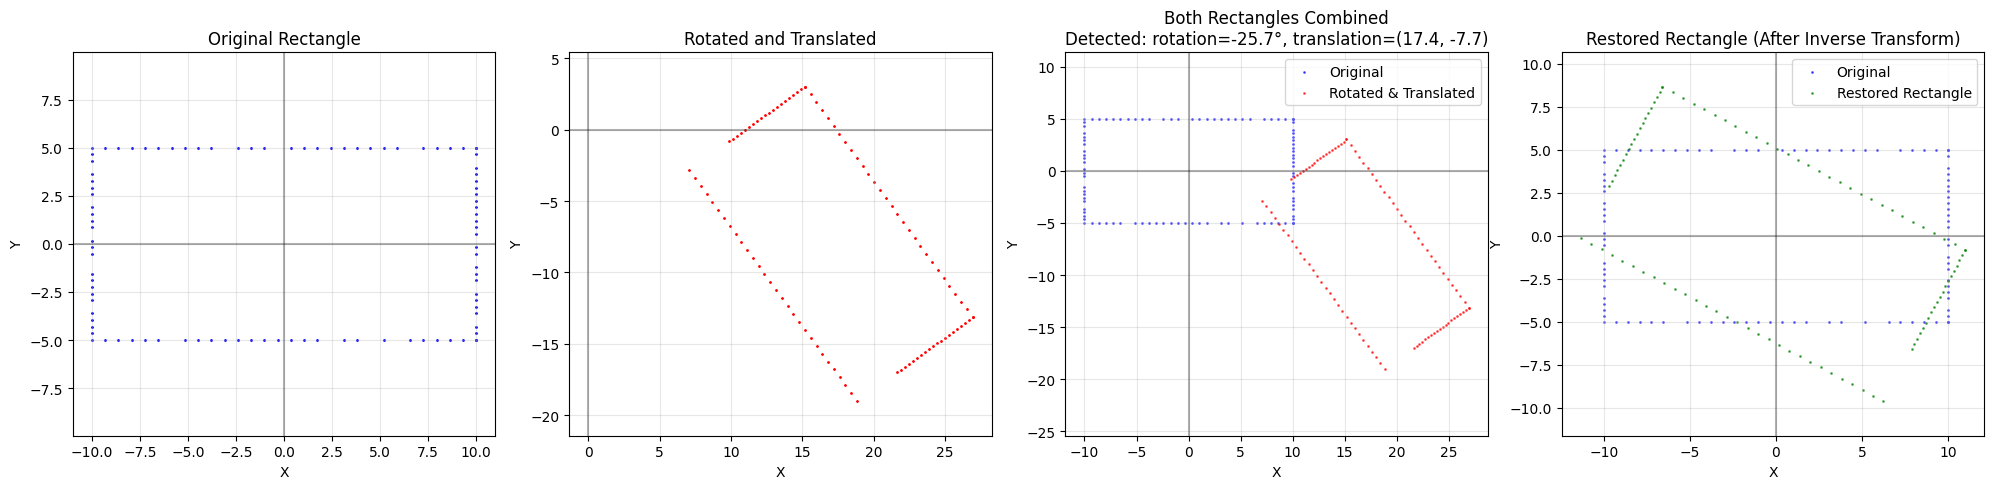

Restoration error (RMS): 10.510998


In [43]:
import numpy as np
import matplotlib.pyplot as plt

def create_map(length, width):
    points = []
    half_length = length / 2
    half_width = width / 2

    for x in np.linspace(-half_length, half_length, 30):
        points.append([x, -half_width])
        points.append([x, half_width])

    for y in np.linspace(-half_width, half_width, 30):
        points.append([-half_length, y])
        points.append([half_length, y])

    return np.array(points)

def rotate_points(points, angle_deg):
    angle_rad = np.radians(angle_deg)
    rotation_matrix = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad), np.cos(angle_rad)]
    ])
    return np.dot(points, rotation_matrix.T)

def translate_points(points, dx, dy):
    return points + np.array([dx, dy])

def find_transform(source_points, target_points):
    source_center = np.mean(source_points, axis=0)
    target_center = np.mean(target_points, axis=0)

    translation = target_center - source_center

    source_centered = source_points - source_center
    target_centered = target_points - target_center

    H = np.dot(source_centered.T, target_centered)
    U, S, Vt = np.linalg.svd(H)
    R = np.dot(Vt.T, U.T)

    angle_rad = np.arctan2(R[1, 0], R[0, 0])
    angle_deg = np.degrees(angle_rad)

    return angle_deg, translation[0], translation[1]

def inverse_transform(points, angle_deg, dx, dy):
    points_translated = translate_points(points, -dx, -dy)
    points_rotated = rotate_points(points_translated, -angle_deg)
    return points_rotated

def remove_random_points(points, n):
    if n >= len(points):
        return np.array([])
    indices = np.random.choice(len(points), len(points) - n, replace=False)
    return points[indices]

def remove_last_points(points, n):
    if n >= len(points):
        return np.array([])
    return points[:-n]

rect1 = create_map(20, 10)
rect2 = create_map(20, 10)

rect2 = rotate_points(rect2, 126)
rect2 = translate_points(rect2, 17, -8)

rect1 = remove_random_points(rect1, 20)
rect2 = remove_last_points(rect2, 20)

print(f"Rectangle 1 points after removing 20 random: {len(rect1)}")
print(f"Rectangle 2 points after removing 20 from end: {len(rect2)}")

min_len = min(len(rect1), len(rect2))
rect1_aligned = rect1[:min_len]
rect2_aligned = rect2[:min_len]

angle, dx, dy = find_transform(rect1, rect2)

print(f"Detected rotation: {angle:.2f} degrees")
print(f"Detected translation: dx = {dx:.2f}, dy = {dy:.2f}")

rect2_restored = inverse_transform(rect2, angle, dx, dy)

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.scatter(rect1[:, 0], rect1[:, 1], s=1, c='blue')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title('Original Rectangle')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(1, 4, 2)
plt.scatter(rect2[:, 0], rect2[:, 1], s=1, c='red')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title('Rotated and Translated')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(1, 4, 3)
plt.scatter(rect1[:, 0], rect1[:, 1], s=1, c='blue', alpha=0.6, label='Original')
plt.scatter(rect2[:, 0], rect2[:, 1], s=1, c='red', alpha=0.6, label='Rotated & Translated')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title(f'Both Rectangles Combined\nDetected: rotation={angle:.1f}°, translation=({dx:.1f}, {dy:.1f})')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.subplot(1, 4, 4)
plt.scatter(rect1[:, 0], rect1[:, 1], s=1, c='blue', alpha=0.6, label='Original')
plt.scatter(rect2_restored[:, 0], rect2_restored[:, 1], s=1, c='green', alpha=0.6, label='Restored Rectangle')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title('Restored Rectangle (After Inverse Transform)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.tight_layout()
plt.show()

error = np.mean(np.sqrt(np.sum((rect1 - rect2_restored)**2, axis=1)))
print(f"Restoration error (RMS): {error:.6f}")